## **Import libraries**

In [1]:
import os
import re
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd
from pathlib import Path

from natsort import natsorted

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner
)
from SARVI.services.common.re_funcs import (
    initialize_re_model,
    undersample_re_negatives, remap_re_relation_labels
)
from SARVI.services.sync_funcs.re_funcs import(
    prepare_data as prepare_data_SYNC,
    construct_loader_re as construct_loader_re_SYNC,
    run_re_classifier as run_re_classifier_SYNC
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

from SARVI.models.losses import MoMLoss

from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

WARNING 06-11 17:52:36 [config.py:70] Support for Transformers v4 is deprecated. The Transformers v4 codepath will become unmaintained in vLLM v0.22.0 and will be removed in vLLM v0.24.0. Please upgrade to Transformers v5: pip install --upgrade transformers


Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: "PipelineContext"):
    print("\n\033[1m0. Initializing variables\033[0m\n\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################
    print("\n\033[1m0.1. Reading ICD10 dictionaries\033[0m\n\n")

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())

    if ctx.ussage == "generative":
        print("\n\033[1m0.2. Initializing LLM\033[0m\n\n")

        # llm = load_llm(ctx.llm_config)
        # prompt = textwrap.dedent(prompts_total["report_to_data"])
        llm = None
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        modelo_re = None
        modelo_att = None
        tokenizer_re = None
        tokenizer_att = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_NER = None
        id2label_NER = None
        label2id_RE = None
        id2label_RE = None
        label2id_ATT = None
        id2label_ATT = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        re_token_distance_bins = None
        re_negative_difficulty_by_bin = None
        icd10_thresholds = None
        root = None
    else:
        pass
        # llm = None
        # prompt = None

        # # ------------------------------NER------------------------------
        # # [BIO, Span]
        # print("\n\033[1m0.2. Initializing NER Models\033[0m\n\n")

        # id2label_ner_bio = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CT-EBM-SP/id2label_bio_nerclassifier.json")
        # id2label_ner_bio = {int(k): v for k, v in id2label_ner_bio.items()}
        # label2id_ner_bio = {v: int(k)  for k, v in id2label_ner_bio.items()}

        # id2label_ner_span = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CT-EBM-SP/id2label_span_nerclassifier.json")
        # id2label_ner_span = {int(k): v for k, v in id2label_ner_span.items()}
        # label2id_ner_span = {v: int(k)  for k, v in id2label_ner_span.items()}

        # id2label_NER = [id2label_ner_bio, id2label_ner_span]
        # label2id_NER = [label2id_ner_bio, label2id_ner_span]

        # modelo_ner = [
        #     initialize_bio_ner_model(ctx, None, len(id2label_ner_bio), "NERTraining/BIO/CT-EBM-SP/bio_nerclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name),
        #     initialize_span_ner_model(ctx, None, len(id2label_ner_span), id2label_ner_span, label2id_ner_span, None, "NERTraining/Span/CT-EBM-SP/span_nerclassifier_checkpoint.pt", True, base_encoder_name=ctx.base_encoder_name)
        # ]

        # # ------------------------------RE------------------------------
        # # [Experience, Negation, Speculation, Time]
        # print("\n\033[1m0.3. Initializing RE Models\033[0m\n\n")

        # re_token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
        # re_negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

        # id2label_re_experience = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_LIVB/id2label_diso_livb_reclassifier.json")
        # id2label_re_experience = {int(k): v for k, v in id2label_re_experience.items()}
        # label2id_re_experience = {v: int(k)  for k, v in id2label_re_experience.items()}

        # id2label_re_negation = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Negcue/id2label_diso_negcue_reclassifier.json")
        # id2label_re_negation = {int(k): v for k, v in id2label_re_negation.items()}
        # label2id_re_negation = {v: int(k)  for k, v in id2label_re_negation.items()}

        # id2label_re_speculation = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Speccue/id2label_diso_speccue_reclassifier.json")
        # id2label_re_speculation = {int(k): v for k, v in id2label_re_speculation.items()}
        # label2id_re_speculation = {v: int(k)  for k, v in id2label_re_speculation.items()}

        # id2label_re_time = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Date/id2label_diso_date_reclassifier.json")
        # id2label_re_time = {int(k): v for k, v in id2label_re_time.items()}
        # label2id_re_time = {v: int(k)  for k, v in id2label_re_time.items()}

        # id2label_RE = [id2label_re_experience, id2label_re_negation, id2label_re_speculation, id2label_re_time]
        # label2id_RE = [label2id_re_experience, label2id_re_negation, label2id_re_speculation, label2id_re_time]

        # tokenizer_re = [
        #     ensure_entity_marker_tokens(None, ["DISO", "LIVB"], "re", base_encoder_name=ctx.base_encoder_name),
        #     ensure_entity_marker_tokens(None, ["DISO", "Neg_cue"], "re", base_encoder_name=ctx.base_encoder_name),
        #     ensure_entity_marker_tokens(None, ["DISO", "Spec_cue"], "re", base_encoder_name=ctx.base_encoder_name),
        #     ensure_entity_marker_tokens(None, ["DISO", "Date"], "re", base_encoder_name=ctx.base_encoder_name)
        # ]

        # modelo_re = [
        #     initialize_re_model(ctx, None, len(id2label_re_experience), len(re_token_distance_bins), "RETraining/DISO_LIVB/diso_livb_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[0]),
        #     initialize_re_model(ctx, None, len(id2label_re_negation), len(re_token_distance_bins), "RETraining/DISO_Negcue/diso_negcue_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[1]),
        #     initialize_re_model(ctx, None, len(id2label_re_speculation), len(re_token_distance_bins), "RETraining/DISO_Speccue/diso_speccue_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[2]),
        #     initialize_re_model(ctx, None, len(id2label_re_time), len(re_token_distance_bins), "RETraining/DISO_Date/diso_date_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[3])
        # ]

        # # ------------------------------ATT------------------------------
        # # [Status]
        # print("\n\033[1m0.4. Initializing ATT Model\033[0m\n\n")

        # id2label_att_status = read_json_single(ctx.paths.docs_dir / "ATTTraining/Status/id2label_status_attclassifier.json")
        # id2label_att_status = {int(k): v for k, v in id2label_att_status.items()}
        # label2id_att_status = {v: int(k)  for k, v in id2label_att_status.items()}

        # id2label_ATT = [id2label_att_status]
        # label2id_ATT = [label2id_att_status]

        # tokenizer_att = [
        #     ensure_entity_marker_tokens(None, ["DISO"], "att", base_encoder_name=ctx.base_encoder_name)
        # ]

        # modelo_att = [
        #     initialize_att_model(ctx, None, len(id2label_att_status), "ATTTraining/Status/status_attclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_att[0])
        # ]

        # # ------------------------------ICD10------------------------------
        # # [NO HS, HS]
        # print("\n\033[1m0.5. Initializing ICD10 Models\033[0m\n\n")

        # node_list = load_tree_hierarchical_module(df_reference)
        # root = node_list["root"]
        # root.set_indexes()

        # id2label_icd_nohs = read_json_single(ctx.paths.docs_dir / "ICDTraining/NO_HS/id2label_icd_pred_nohs.json")
        # id2label_icd_nohs = {int(k): v for k, v in id2label_icd_nohs.items()}
        # label2id_icd_nohs = {v: int(k)  for k, v in id2label_icd_nohs.items()}

        # id2label_icd_hs = read_json_single(ctx.paths.docs_dir / "ICDTraining/HS/id2label_icd_pred_hs.json")
        # id2label_icd_hs = {int(k): v for k, v in id2label_icd_hs.items()}
        # label2id_icd_hs = {v: int(k)  for k, v in id2label_icd_hs.items()}

        # id_no_hs_to_id_hs = {id_no_hs: label2id_icd_hs[label_name] for label_name, id_no_hs in label2id_icd_nohs.items()}

        # id2label_ICD10 = [id2label_icd_nohs, id2label_icd_hs]
        # label2id_ICD10 = [label2id_icd_nohs, label2id_icd_hs]
        # icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")

        # modelo_icd10_head = [
        #     initialize_icd10_no_hs_head_model(ctx, None, None, ctx.paths.docs_dir / "ICDTraining/NO_HS/icd_pred_nohs_checkpoint.pt", label2id_icd_nohs, root, base_encoder_name=ctx.base_encoder_name),
        #     initialize_icd10_hs_head_model(ctx, None, None, ctx.paths.docs_dir / "ICDTraining/HS/icd_pred_hs_checkpoint.pt", root, base_encoder_name=ctx.base_encoder_name)
        # ]
        # modelo_icd10_prediction = [
        #     None,
        #     initialize_icd10_hs_prediction_model(ctx, ctx.paths.docs_dir / "ICDTraining/HS/icd_pred_hs_predictor_checkpoint.pt", label2id_icd_hs, root)
        # ]

    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        modelo_re=modelo_re,
        modelo_att=modelo_att,
        tokenizer_re=tokenizer_re,
        tokenizer_att=tokenizer_att,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_NER = label2id_NER,
        id2label_NER = id2label_NER,
        label2id_RE = label2id_RE,
        id2label_RE = id2label_RE,
        label2id_ATT = label2id_ATT,
        id2label_ATT = id2label_ATT,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        re_token_distance_bins=re_token_distance_bins,
        re_negative_difficulty_by_bin=re_negative_difficulty_by_bin,
        icd10_thresholds=icd10_thresholds,
        root=root
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="generative",
    folder_and_archive_name="CT-EBM-SP-v3/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    base_encoder_name="IIC/RigoBERTa-Clinical",
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)


0. Initializing variables



0.1. Reading ICD10 dictionaries





0.2. Initializing LLM




## **Run RE data creation**

In [4]:
"""
data_prepared = [
    [  # file/text 0
        {example for pair T1-T2},
        {example for pair T1-T3},
        ...
    ],
    [  # file/text 1
        {example for pair T4-T5},
        ...
    ],
    ...
]


{
    "input_ids": [...],
    "attention_mask": [...],
    "position_ids": [...],
    "original_position_ids": [...],
    "marker_positions": {
        "<S:DISO>": [3],
        "</S:DISO>": [5],
        "<O:Date>": [14],
        "</O:Date>": [19],
    },
    "marked_text": "... <S:DISO>diabetes</S:DISO> ... <O:Date>ayer</O:Date> ...",
    "left_entity": {...},
    "right_entity": {...},
    "file_name": "...",
}
"""

'\ndata_prepared = [\n    [  # file/text 0\n        {example for pair T1-T2},\n        {example for pair T1-T3},\n        ...\n    ],\n    [  # file/text 1\n        {example for pair T4-T5},\n        ...\n    ],\n    ...\n]\n\n\n{\n    "input_ids": [...],\n    "attention_mask": [...],\n    "position_ids": [...],\n    "original_position_ids": [...],\n    "marker_positions": {\n        "<S:DISO>": [3],\n        "</S:DISO>": [5],\n        "<O:Date>": [14],\n        "</O:Date>": [19],\n    },\n    "marked_text": "... <S:DISO>diabetes</S:DISO> ... <O:Date>ayer</O:Date> ...",\n    "left_entity": {...},\n    "right_entity": {...},\n    "file_name": "...",\n}\n'

### **Create data**

In [5]:
TEMPORAL_ENTITY_LABELS = {"Date", "Time"}
TEMPORAL_OVERLAP_ROLES = {"OVERLAP", "SIMULTANEOUS", "CONTAINS"}

ENTITY_LINE_RE = re.compile(r"^(T\S+)\t([^\s]+)\s+(.+?)\t(.*)$")
RELATION_LINE_RE = re.compile(r"^(R\S+)\t(\S+)\s+Arg1:(T\S+)\s+Arg2:(T\S+)")
E3C_RELATION_ROLE_RE = re.compile(r"RelationRole\s+\S+\s+rid=\S+\s+role=([^\s]+)")


def map_temporal_role_to_general_label(role: str, temp_is_arg1: bool) -> str | None:
    role = role.upper()

    if role == "BEFORE":
        return "After" if temp_is_arg1 else "Before"

    if role == "AFTER":
        return "Before" if temp_is_arg1 else "After"

    if role == "BEGINS-ON":
        return "After"

    if role == "ENDS-ON":
        return "Before"

    if role in TEMPORAL_OVERLAP_ROLES:
        return "Overlap"

    return None


def generalize_temporal_entity_label(label: str) -> str:
    return "Date" if label in TEMPORAL_ENTITY_LABELS else "DISO"


def parse_generalized_entities_from_lines(lines: list[str]) -> tuple[dict[str, str], list[str]]:
    entity_labels_by_id = {}
    generalized_t_lines = []

    for line in lines:
        match = ENTITY_LINE_RE.match(line)
        if match is None:
            continue

        entity_id, label, boundaries, text = match.groups()
        generalized_label = generalize_temporal_entity_label(label)
        entity_labels_by_id[entity_id] = generalized_label
        generalized_t_lines.append(f"{entity_id}\t{generalized_label} {boundaries}\t{text}")

    return entity_labels_by_id, generalized_t_lines


def build_generalized_relation_line(relation_id: str, relation_role: str, arg1_id: str, arg2_id: str, entity_labels_by_id: dict[str, str]) -> str | None:
    arg1_label = entity_labels_by_id.get(arg1_id)
    arg2_label = entity_labels_by_id.get(arg2_id)

    if arg1_label is None or arg2_label is None:
        return None

    arg1_is_temporal = arg1_label == "Date"
    arg2_is_temporal = arg2_label == "Date"

    if arg1_is_temporal == arg2_is_temporal:
        return None

    mapped_label = map_temporal_role_to_general_label(relation_role, temp_is_arg1=arg1_is_temporal)
    if mapped_label is None:
        return None

    return f"{relation_id}\t{mapped_label} Arg1:{arg1_id} Arg2:{arg2_id}"


def generalize_ct_ebm_ann_data(ann_data: dict[str, list[str]]) -> dict[str, list[str]]:
    entity_labels_by_id, generalized_t_lines = parse_generalized_entities_from_lines(ann_data.get("T", []))
    generalized_r_lines = []

    for line in ann_data.get("R", []):
        match = RELATION_LINE_RE.match(line)
        if match is None:
            continue

        relation_id, relation_label, arg1_id, arg2_id = match.groups()
        generalized_relation = build_generalized_relation_line(relation_id=relation_id, relation_role=relation_label, arg1_id=arg1_id, arg2_id=arg2_id, entity_labels_by_id=entity_labels_by_id)
        if generalized_relation is not None:
            generalized_r_lines.append(generalized_relation)

    return {"T": generalized_t_lines, "R": generalized_r_lines}


def generalize_e3c_ann_file(ann_path: Path) -> dict[str, list[str]]:
    lines = ann_path.read_text(encoding="utf-8", errors="replace").splitlines()
    entity_labels_by_id, generalized_t_lines = parse_generalized_entities_from_lines(lines)
    generalized_r_lines = []
    pending_relation_role = None

    for line in lines:
        role_match = E3C_RELATION_ROLE_RE.search(line)
        if role_match is not None:
            pending_relation_role = role_match.group(1)
            continue

        relation_match = RELATION_LINE_RE.match(line)
        if relation_match is None:
            continue

        relation_id, fallback_relation_label, arg1_id, arg2_id = relation_match.groups()
        relation_role = pending_relation_role or fallback_relation_label
        pending_relation_role = None

        generalized_relation = build_generalized_relation_line(relation_id=relation_id, relation_role=relation_role, arg1_id=arg1_id, arg2_id=arg2_id, entity_labels_by_id=entity_labels_by_id)
        if generalized_relation is not None:
            generalized_r_lines.append(generalized_relation)

    return {"T": generalized_t_lines, "R": generalized_r_lines}


def load_general_temporal_re_data(dataset_specs: list[tuple[str, Path]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    data_rows = []
    ann_rows = []

    for dataset_name, folder_path in dataset_specs:
        folder_path = Path(folder_path)
        text_by_file = read_txt_list(folder_path)

        if dataset_name == "E3C":
            ann_by_file = {
                ann_path.stem: generalize_e3c_ann_file(ann_path)
                for ann_path in folder_path.glob("*.ann")
            }
        elif dataset_name == "CT-EBM-SP-v3":
            ann_by_file = {
                file_name: generalize_ct_ebm_ann_data(ann_data)
                for file_name, ann_data in read_ann_list(folder_path).items()
            }
        else:
            raise ValueError(f"Unsupported temporal RE dataset: {dataset_name}")

        for file_name, text in text_by_file.items():
            ann_data = ann_by_file.get(file_name)
            if ann_data is None:
                continue

            prefixed_file_name = f"{dataset_name}::{file_name}"
            data_rows.append({"archivo_origen": prefixed_file_name, "Text": text})
            ann_rows.append({"archivo_origen": prefixed_file_name, **ann_data})

    return pd.DataFrame(data_rows), pd.DataFrame(ann_rows)

In [6]:
token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

print("1.1. Creating RE data // Train data")
df_data_train, df_ann_train = load_general_temporal_re_data([("CT-EBM-SP-v3", ctx.paths.data_input / "CT-EBM-SP-v3/train"), ("E3C", ctx.paths.data_input / "E3C/train")])

print("Train files:", len(df_data_train))

data_prepared_train, all_relation_labels_train, file_names_train, preparation_warnings_train, tokenizer_re = prepare_data_SYNC(data=df_data_train, data_ann=df_ann_train, entity_label_1="DISO", entity_label_2="Date", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                                               token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=True)
model_ner.resize_token_embeddings(len(tokenizer_re))

data_prepared_train, all_relation_labels_train = undersample_re_negatives(data_prepared_train, all_relation_labels_train, outside_label="O", 
                                                                                        max_hard_negative_ratio=2, max_medium_negative_ratio=3, max_easy_negative_ratio=1, seed=SEED)

print("1.1. Creating RE data // Dev data")
df_data_dev, df_ann_dev = load_general_temporal_re_data([("CT-EBM-SP-v3", ctx.paths.data_input / "CT-EBM-SP-v3/dev"), ("E3C", ctx.paths.data_input / "E3C/dev")])

print("Dev files:", len(df_data_dev))

data_prepared_dev, all_relation_labels_dev, file_names_dev, preparation_warnings_dev = prepare_data_SYNC(data=df_data_dev, data_ann=df_ann_dev, entity_label_1="DISO", entity_label_2="Date", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                         token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=False)


1.1. Creating RE data // Train data


Train files: 768


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/768 [00:00<?, ?text/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (529 > 512). Running this sequence through the model will result in indexing errors


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


1.1. Creating RE data // Dev data
Dev files: 256


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/256 [00:00<?, ?text/s]

> Example of label output

**COMPROBATE ALL // MODEL CREATION NEXT**

## **Run RE model**

In [7]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loader_re_SYNC(data_prepared_train, relation_labels=all_relation_labels_train, 
                                                                                          file_names=file_names_train, seed=SEED, batch_size=32)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loader_re_SYNC(data_prepared_dev, all_relation_labels_dev, 
                                                                        file_names=file_names_dev, label2id=label2id, id2label=id2label, seed=SEED, batch_size=32)

modelo_re = initialize_re_model(ctx, model_ner, len(id2label), len(token_distance_bins), None)

ignore_index = -100
class_counts = torch.zeros(len(label2id), dtype=torch.float)
for batch in data_loader_full_train:
    labels = batch["relation_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    if valid_labels.numel() > 0:
        class_counts += torch.bincount(valid_labels.cpu(), minlength=len(label2id)).float()
mom_M = max(int(class_counts[label2id["O"]].item()), 1)
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum() * len(label2id)
weights = weights.to(ctx.device)

optimizer = torch.optim.AdamW(modelo_re.parameters(), lr=2e-5, weight_decay=0.001)
criterion = MoMLoss(M=mom_M, majority_label=label2id["O"], delta=0.05,
                    # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
                    sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    ignore_index=ignore_index)

In [8]:
id2label

{0: 'O', 1: 'Overlap', 2: 'Before', 3: 'After'}

In [9]:
from collections import defaultdict

In [10]:
total_o = defaultdict(int)
total_after = defaultdict(int)
total_overlap = defaultdict(int)
total_before = defaultdict(int)

for i in data_loader_full_dev:
    for label, count in zip(i["relation_labels"].detach(), i["middle_token_count"].detach()):
        if label == 0:
            total_o[count.item()] += 1
        elif label == 1:
            total_overlap[count.item()] += 1
        elif label == 2:
            total_before[count.item()] += 1
        else:
            total_after[count.item()] += 1
    

In [11]:
## DISO - Date

total_o, total_after, total_overlap, total_before

(defaultdict(int,
             {258: 84,
              254: 69,
              247: 68,
              245: 69,
              239: 78,
              224: 91,
              214: 94,
              206: 127,
              200: 134,
              203: 126,
              187: 145,
              174: 150,
              166: 157,
              151: 208,
              143: 171,
              122: 157,
              60: 144,
              33: 148,
              29: 140,
              24: 141,
              3: 91,
              106: 182,
              109: 163,
              147: 177,
              192: 164,
              205: 135,
              215: 137,
              225: 75,
              228: 81,
              115: 154,
              118: 197,
              156: 157,
              201: 146,
              234: 89,
              237: 81,
              233: 86,
              119: 172,
              160: 188,
              218: 91,
              238: 88,
              241: 74,
              104: 1

In [12]:
seed_everything(SEED)

print("1.2. Running RE model")
results = run_re_classifier_SYNC(modelo_re, data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=100, patience=10, ignore_index=ignore_index, label_key="relation_labels", return_predictions=False)

write_torch_checkpoint(ctx=ctx, name="RETraining/DISO_Date_GENERAL/diso_date_reclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="RETraining/DISO_Date_GENERAL/diso_date_reclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="RETraining/DISO_Date_GENERAL/id2label_diso_date_reclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="RETraining/DISO_Date_GENERAL/label2id_diso_date_reclassifier", content=label2id)

1.2. Running RE model


RE / Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

RE / Training epoch 1 / Train set:   0%|          | 0/387 [00:00<?, ?batch/s]

RE / Training epoch 1 / Dev set:   0%|          | 0/1280 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

       After     0.0081    0.6750    0.0160        40
      Before     0.0026    0.7273    0.0052        44
           O     0.9997    0.5900    0.7421     40446
     Overlap     0.1314    0.4485    0.2032       408

    accuracy                         0.5888     40938
   macro avg     0.2854    0.6102    0.2416     40938
weighted avg     0.9890    0.5888    0.7352     40938



...

RE / Training epoch 30 / Dev set:   0%|          | 0/1280 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

       After     0.1212    0.4000    0.1860        40
      Before     0.1242    0.4545    0.1951        44
           O     0.9968    0.9768    0.9867     40446
     Overlap     0.2932    0.7279    0.4180       408

    accuracy                         0.9732     40938
   macro avg     0.3839    0.6398    0.4465     40938
weighted avg     0.9880    0.9732    0.9794     40938

Epoch 30/100 | train loss: 0.000372 | dev loss: 0.001002 | Best F1 (macro): 0.5372


RE / Training epoch 31 / Train set:   0%|          | 0/387 [00:00<?, ?batch/s]

RE / Training epoch 31 / Dev set:   0%|          | 0/1280 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

       After     0.0379    0.4750    0.0702        40
      Before     0.1121    0.5682    0.1873        44
           O     0.9973    0.9696    0.9833     40446
     Overlap     0.3202    0.6985    0.4391       408

    accuracy                         0.9660     40938
   macro avg     0.3669    0.6778    0.4200     40938
weighted avg     0.9886    0.9660    0.9761     40938


Early stopping at epoch 31 | Best epoch: 21 | Best dev macro F1: 0.537180


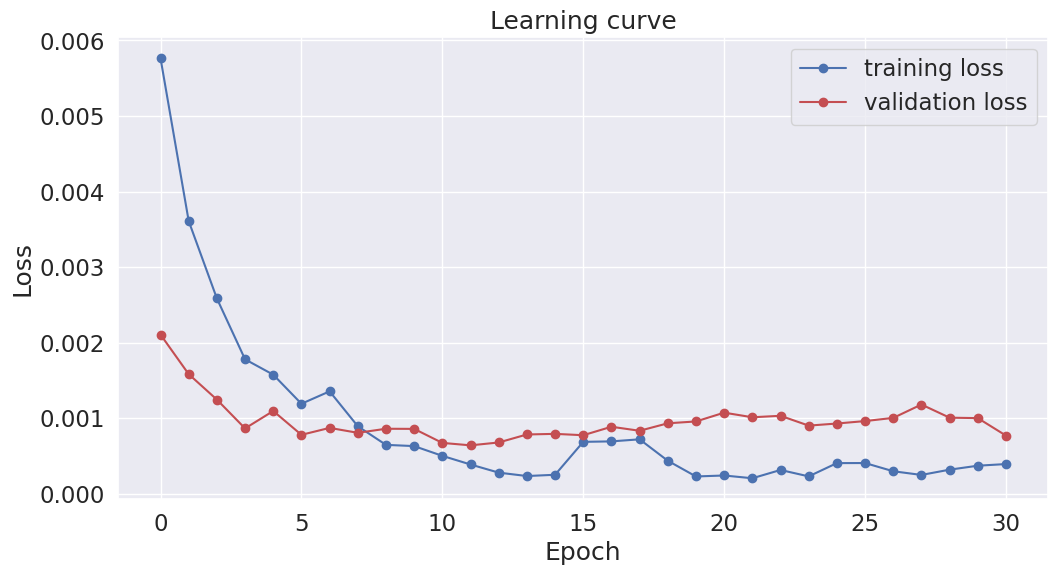

In [13]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## **Eval model**

In [14]:
token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

print("1.1. Creating RE data // Test data")
df_data_test, df_ann_test = load_general_temporal_re_data([
    ("CT-EBM-SP-v3", ctx.paths.data_input / "CT-EBM-SP-v3/test"),
    ("E3C", ctx.paths.data_input / "E3C/test"),
])

print("Test files:", len(df_data_test))

data_prepared_test, all_relation_labels_test, file_names_test, preparation_warnings_test = prepare_data_SYNC(data=df_data_test, data_ann=df_ann_test, entity_label_1="DISO", entity_label_2="Date", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                         token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=False)


1.1. Creating RE data // Test data
Test files: 257


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/257 [00:00<?, ?text/s]

In [15]:
id2label = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Date_GENERAL/id2label_diso_date_reclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Date_GENERAL/label2id_diso_date_reclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loader_re_SYNC(data_prepared_test, all_relation_labels_test, 
                                                                        file_names=file_names_test, label2id=label2id, id2label=id2label, seed=SEED, batch_size=16)

modelo_re = initialize_re_model(ctx, model_ner, len(id2label), len(token_distance_bins), "RETraining/DISO_Date_GENERAL/diso_date_reclassifier_checkpoint.pt")

In [16]:
total_o = defaultdict(int)
total_after = defaultdict(int)
total_overlap = defaultdict(int)
total_before = defaultdict(int)

for i in data_loader_full_test:
    for label, count in zip(i["relation_labels"].detach(), i["middle_token_count"].detach()):
        if label == 0:
            total_o[count.item()] += 1
        elif label == 1:
            total_overlap[count.item()] += 1
        elif label == 2:
            total_before[count.item()] += 1
        else:
            total_after[count.item()] += 1
    

In [17]:
## DISO - Date

total_o, total_after, total_overlap, total_before

(defaultdict(int,
             {7: 126,
              10: 115,
              15: 117,
              27: 122,
              30: 115,
              37: 131,
              41: 133,
              45: 140,
              47: 117,
              57: 156,
              69: 146,
              70: 136,
              77: 126,
              85: 153,
              89: 143,
              97: 149,
              100: 143,
              107: 157,
              112: 136,
              116: 171,
              122: 152,
              128: 144,
              140: 156,
              144: 153,
              148: 150,
              152: 116,
              161: 170,
              163: 164,
              168: 137,
              171: 146,
              182: 125,
              183: 132,
              189: 147,
              196: 118,
              195: 146,
              199: 125,
              201: 129,
              190: 128,
              186: 141,
              180: 132,
              188: 143,
              1

In [18]:
id2label

{0: 'O', 1: 'Overlap', 2: 'Before', 3: 'After'}

In [19]:
results = results = run_re_classifier_SYNC(modelo_re, data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

RE / Inference:   0%|          | 0/2300 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

       After     0.2899    0.5556    0.3810        36
      Before     0.3222    0.5088    0.3946        57
           O     0.9955    0.9904    0.9929     36334
     Overlap     0.4908    0.6531    0.5605       369

    accuracy                         0.9858     36796
   macro avg     0.5246    0.6770    0.5822     36796
weighted avg     0.9887    0.9858    0.9871     36796

